# **Lab 04.2 - Policy-Based Reinforcement Learning for Edge Offloading**


##### Copyright by UIT-NC@NT549

## **Some instructions before getting started**:
<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">

Start the Kernel: At the top right, choose <strong>Select Kernel ➞ Python Environments...</strong>

You can run all code blocks to check: From the menu bar, choose <strong>Run All</strong>.

Complete all code blocks marked with the comment <span style="font-family: monospace; font-weight: bold; color:white; background-color: green;"> ### YOU NEED TO WRITE YOUR CODE BELOW ### </span>

This lab consists of 7 practical sections:
<ol style="margin-left: 20px;">
  <li><strong>Part 1: Build EdgeOffloadingEnv and Validate Environment Behavior</strong> (2-layer system: device and edge, check_env and short rollout))</li>
  <li><strong>Part 2: Baseline Policies</strong> (random, device-only, edge-only, greedy)</li>
  <li><strong>Part 3: REINFORCE</strong> (from scratch)</li>
  <li><strong>Part 4: Actor-Critic</strong> (from scratch)</li>
  <li><strong>Part 5: A2C</strong> (Stable-Baselines3)</li>
  <li><strong>Part 6: Final Comparison + Reflection</strong></li>
</ol>
</div>

In [1]:
# ============================================================================
# Imports and runtime stability config
# ============================================================================

import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

# Limit PyTorch threading for kernel stability on macOS
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

# Reproducibility
SEED = 42
FAST_MODE = True
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device info
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')
print(f'NumPy: {np.__version__}')
print(f'Gymnasium: {gym.__version__}')
print(f'FAST_MODE: {FAST_MODE}')

# Shared plotting helpers
plt.rcParams.update({
    'figure.figsize': (10, 4),
    'axes.grid': True,
    'grid.alpha': 0.25,
})

def moving_average(values, window=20):
    """Smooth a learning curve using a moving average."""
    if len(values) == 0:
        return np.array([])
    return pd.Series(values).rolling(window=window, min_periods=1).mean().to_numpy()


def plot_curve(values, title, ylabel, window=20):
    """Plot raw values together with a moving average."""
    x = np.arange(1, len(values) + 1)
    plt.figure(figsize=(10, 4))
    plt.plot(x, values, alpha=0.35, label='Episode value')
    plt.plot(x, moving_average(values, window), lw=2, label=f'{window}-episode moving average')
    plt.title(title)
    plt.xlabel('Episode')
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()


def evaluate_edge_policy(env_fn, action_fn, episodes=100):
    """Evaluate a policy on EdgeOffloadingEnv and return summary metrics."""
    episode_rewards, episode_avg_latencies, all_latencies = [], [], []
    action_counts = np.zeros(2, dtype=np.int64)

    for ep in range(episodes):
        env = env_fn(SEED + 2000 + ep)
        state, _ = env.reset(seed=SEED + 2000 + ep)

        done = False
        rewards, latencies = [], []

        while not done:
            action = int(action_fn(state, env))
            state, reward, terminated, truncated, info = env.step(action)
            rewards.append(reward)
            latencies.append(info['latency'])
            action_counts[action] += 1
            done = terminated or truncated

        env.close()
        episode_rewards.append(float(np.sum(rewards)))
        episode_avg_latencies.append(float(np.mean(latencies)))
        all_latencies.extend(latencies)

    all_latencies = np.array(all_latencies, dtype=np.float32)
    total_actions = int(action_counts.sum())

    return {
        'episode_rewards': np.array(episode_rewards, dtype=np.float32),
        'episode_avg_latencies': np.array(episode_avg_latencies, dtype=np.float32),
        'all_latencies': all_latencies,
        'action_counts': action_counts,
        'avg_latency': float(np.mean(all_latencies)),
        'p95_latency': float(np.percentile(all_latencies, 95)),
        'avg_reward': float(np.mean(episode_rewards)),
        'device_pct': float(action_counts[0] / total_actions * 100.0),
        'edge_pct': float(action_counts[1] / total_actions * 100.0),
    }

Device: cpu
PyTorch: 2.12.0+cu130
NumPy: 2.4.4
Gymnasium: 1.2.3
FAST_MODE: True


In [ ]:
print("\n" + "="*60)
print("PART 1: EDGE OFFLOADING ENVIRONMENT")
print("="*60)

class EdgeOffloadingEnv(gym.Env):
    """Custom edge offloading environment for RL training.
    
    State: [input_size, workload, uplink_rate, edge_queue]
    Actions: 0 = device execution, 1 = edge offloading
    Reward: -latency (minimizing latency)
    """

    metadata = {'render_modes': ['human']}

    def __init__(self, max_steps=50):
        """Initialize environment parameters.
        
        Args:
            max_steps: Maximum steps per episode
        """
        super().__init__()
        self.f_device = 1.0
        self.f_edge = 5.0
        self.max_steps = max_steps

        low  = np.array([1.0,  0.1,  2.0,   0.0], dtype=np.float32)
        high = np.array([20.0, 3.0, 20.0, 200.0], dtype=np.float32)
        self.observation_space = spaces.Box(low=low, high=high, dtype=np.float32)
        self.action_space = spaces.Discrete(2)

        self.state = None
        self.step_count = 0

    def _sample_state(self):
        """Sample a new random state.
        
        Returns:
            State array: [input_size, workload, uplink_rate, edge_queue]
        """
        input_size  = self.np_random.uniform(1.0,  20.0)
        workload    = self.np_random.uniform(0.1,   3.0)
        uplink_rate = self.np_random.uniform(2.0,  20.0)
        edge_queue  = self.np_random.uniform(0.0, 200.0)
        return np.array([input_size, workload, uplink_rate, edge_queue], dtype=np.float32)

    def _compute_latencies(self, state):
        """Compute execution latencies for device and edge.
        
        Args:
            state: Current state [input_size, workload, uplink_rate, edge_queue]
            
        Returns:
            Tuple (latency_device, latency_edge) in milliseconds
        """
        input_size, workload, uplink_rate, edge_queue = state
        t_device = (workload / self.f_device) * 1000.0
        t_upload = (input_size / uplink_rate) * 1000.0
        t_edge   = t_upload + edge_queue + (workload / self.f_edge) * 1000.0
        return float(t_device), float(t_edge)

    def reset(self, seed=None, options=None):
        """Reset environment to initial state.
        
        Args:
            seed: Random seed for reproducibility
            options: Additional reset options
            
        Returns:
            Tuple (observation, info)
        """
        super().reset(seed=seed)
        self.step_count = 0
        self.state = self._sample_state()
        return self.state.copy(), {}

    def step(self, action):
        """Execute one step in the environment.
        
        Args:
            action: 0 for device execution, 1 for edge offloading
            
        Returns:
            Tuple (observation, reward, terminated, truncated, info)
        """
        assert self.action_space.contains(action), f"Invalid action: {action}"
        t_device, t_edge = self._compute_latencies(self.state)

        if action == 0:
            selected_latency = t_device
            action_name = "device"
        else:
            selected_latency = t_edge
            action_name = "edge"

        reward = -selected_latency / 1000.0
        self.step_count += 1
        truncated = self.step_count >= self.max_steps
        terminated = False

        info = {
            'latency':        selected_latency,
            'latency_device': t_device,
            'latency_edge':   t_edge,
            'action':         action,
            'action_name':    action_name,
        }

        self.state = self._sample_state()
        return self.state.copy(), reward, terminated, truncated, info

    def render(self):
        """Render current environment state."""
        if self.state is None:
            print('Environment has not been reset yet.')
        else:
            print(f'Step {self.step_count:02d} | state = {np.round(self.state, 3)}')


# Test environment initialization
print("\nInitializing EdgeOffloadingEnv...")
edge_env = EdgeOffloadingEnv(max_steps=50)
obs, info = edge_env.reset(seed=SEED)
print(f'Initial observation: {np.round(obs, 3)}')
print(f'Initial info: {info}')



PART 1: EDGE OFFLOADING ENVIRONMENT

Initializing EdgeOffloadingEnv...
Initial observation: [ 15.705   1.373  17.455 139.474]
Initial info: {}


---

# PART 2: Environment Validation

Before training any policy, we validate environment API behavior and inspect transition outputs using a short random rollout.

In [3]:
# Environment validation and simple rollout test
print("\nValidating environment...")
try:
    from gymnasium.utils.env_checker import check_env
    check_env(edge_env, skip_render_check=True)
    print("✓ check_env passed successfully.")
except Exception as exc:
    print(f"check_env not available or skipped. Details: {exc}")

# Run a few steps to verify correctness
print("\nTest rollout (5 steps):")
obs, info = edge_env.reset(seed=SEED)
print(f"Initial obs: {np.round(obs, 3)}")

for step_idx in range(5):
    action = edge_env.action_space.sample()
    obs, reward, terminated, truncated, info = edge_env.step(action)
    print(f"Step {step_idx + 1}: action={action}, "
          f"reward={reward:.6f}, "
          f"latency={info['latency']:.2f}ms, "
          f"action_name={info['action_name']}")
    
    if terminated or truncated:
        obs, info = edge_env.reset(seed=SEED + step_idx + 1)
        print("  → Episode truncated, reset.")



Validating environment...
✓ check_env passed successfully.

Test rollout (5 steps):
Initial obs: [ 15.705   1.373  17.455 139.474]
Step 1: action=1, reward=-1.313787, latency=1313.79ms, action_name=edge
Step 2: action=1, reward=-0.920735, latency=920.73ms, action_name=edge
Step 3: action=0, reward=-1.406119, latency=1406.12ms, action_name=device
Step 4: action=1, reward=-1.868452, latency=1868.45ms, action_name=edge
Step 5: action=0, reward=-0.285070, latency=285.07ms, action_name=device


---

# PART 3: Baseline Policies and Evaluation

Before training RL algorithms, we establish baseline policies to understand expected latency and reward scales.

### 3.1 Policy Implementations

We implement four baseline policies:
- **Random**: choose action uniformly at random
- **Device-only**: always execute on device
- **Edge-only**: always offload to edge
- **Greedy latency**: choose action with lower immediate latency


In [4]:
# ============================================================================
# Baseline policy functions
# ============================================================================

def random_policy(state, env):
    return env.action_space.sample()

def device_only_policy(state, env):
    return 0

def edge_only_policy(state, env):
    return 1

def greedy_latency_policy(state, env):
    t_device, t_edge = env._compute_latencies(state)
    return 0 if t_device <= t_edge else 1


In [5]:
# ============================================================================
# Evaluate baseline policies
# ============================================================================

def make_env(seed):
    env = EdgeOffloadingEnv(max_steps=50)
    return env

baseline_policies = {
    'Random':          random_policy,
    'Device-only':     device_only_policy,
    'Edge-only':       edge_only_policy,
    'Greedy latency':  greedy_latency_policy,
}

baseline_results = {}
for name, policy_fn in baseline_policies.items():
    result = evaluate_edge_policy(make_env, policy_fn, episodes=100)
    baseline_results[name] = result
    print(f"{name:20s} | Avg Latency: {result['avg_latency']:.2f} ms | "
          f"P95: {result['p95_latency']:.2f} ms | "
          f"Avg Reward: {result['avg_reward']:.4f} | "
          f"Device%: {result['device_pct']:.1f} | Edge%: {result['edge_pct']:.1f}")


Random               | Avg Latency: 1641.77 ms | P95: 3354.39 ms | Avg Reward: -82.0883 | Device%: 50.4 | Edge%: 49.6


Device-only          | Avg Latency: 1533.06 ms | P95: 2847.47 ms | Avg Reward: -76.6532 | Device%: 100.0 | Edge%: 0.0


Edge-only            | Avg Latency: 1754.79 ms | P95: 4478.39 ms | Avg Reward: -87.7394 | Device%: 0.0 | Edge%: 100.0


Greedy latency       | Avg Latency: 1132.28 ms | P95: 2346.86 ms | Avg Reward: -56.6140 | Device%: 49.0 | Edge%: 51.0


---

# PART 4: Actor-Critic on EdgeOffloadingEnv

Actor-Critic combines a policy (actor) and a value estimator (critic) for more stable learning than REINFORCE.

### 5.1 Actor and Critic Networks

- **Actor**: outputs action probabilities
- **Critic**: estimates the state value for temporal-difference learning



PART 4: ACTOR-CRITIC ON EDGE OFFLOADING ENV
Training Actor-Critic...


Training done. Last-50 avg reward: -62.8592


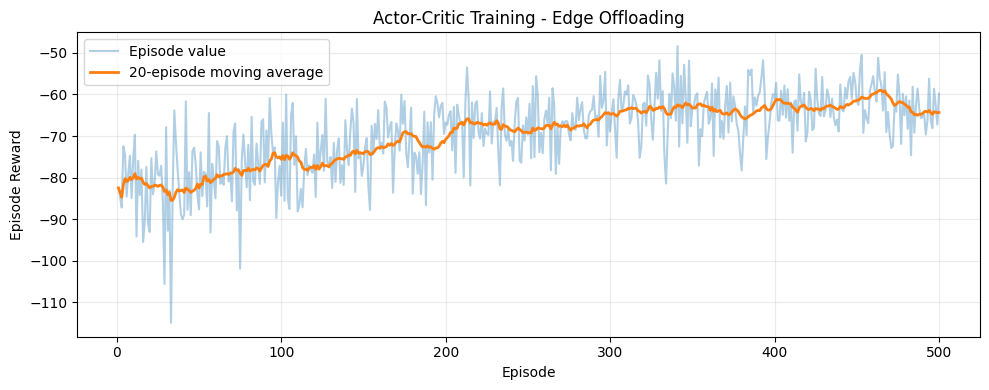

In [6]:
print("\n" + "="*60)
print("PART 4: ACTOR-CRITIC ON EDGE OFFLOADING ENV")
print("="*60)

# ============================================================================
# Actor and Critic networks
# ============================================================================

OBS_LOW  = np.array([1.0,  0.1,  2.0,   0.0], dtype=np.float32)
OBS_HIGH = np.array([20.0, 3.0, 20.0, 200.0], dtype=np.float32)

def normalize_state(state):
    return (np.array(state, dtype=np.float32) - OBS_LOW) / (OBS_HIGH - OBS_LOW)


class ActorNetwork(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
            nn.Softmax(dim=-1),
        )

    def forward(self, x):
        return self.net(x)


class CriticNetwork(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_actor_critic(num_episodes=600, gamma=0.99, lr_actor=3e-4, lr_critic=1e-3, entropy_coef=0.05):
    actor  = ActorNetwork().to(device)
    critic = CriticNetwork().to(device)
    opt_actor  = optim.Adam(actor.parameters(),  lr=lr_actor)
    opt_critic = optim.Adam(critic.parameters(), lr=lr_critic)

    env = EdgeOffloadingEnv(max_steps=50)
    episode_rewards = []

    for ep in range(num_episodes):
        state, _ = env.reset(seed=SEED + ep)
        done = False
        ep_reward = 0.0

        while not done:
            s_norm  = normalize_state(state)
            state_t = torch.tensor(s_norm, dtype=torch.float32, device=device).unsqueeze(0)
            probs   = actor(state_t).squeeze(0)
            dist    = Categorical(probs)
            action  = dist.sample()
            log_prob = dist.log_prob(action)

            next_state, reward, terminated, truncated, _ = env.step(action.item())
            done = terminated or truncated
            ep_reward += reward

            ns_norm      = normalize_state(next_state)
            next_state_t = torch.tensor(ns_norm, dtype=torch.float32, device=device).unsqueeze(0)
            reward_t     = torch.tensor(reward, dtype=torch.float32, device=device)

            value      = critic(state_t)
            with torch.no_grad():
                next_value = critic(next_state_t) if not done else torch.tensor(0.0, device=device)
            td_error = reward_t + gamma * next_value - value

            critic_loss = td_error.pow(2)
            opt_critic.zero_grad()
            critic_loss.backward()
            opt_critic.step()

            entropy = dist.entropy()
            actor_loss = -log_prob * td_error.detach() - entropy_coef * entropy
            opt_actor.zero_grad()
            actor_loss.backward()
            opt_actor.step()

            state = next_state

        episode_rewards.append(ep_reward)

    env.close()
    return actor, episode_rewards


print("Training Actor-Critic...")
_episodes = 500 if FAST_MODE else 1000
ac_actor, ac_rewards = train_actor_critic(num_episodes=_episodes)
print(f"Training done. Last-50 avg reward: {np.mean(ac_rewards[-50:]):.4f}")
plot_curve(ac_rewards, "Actor-Critic Training - Edge Offloading", "Episode Reward")


In [7]:
# ============================================================================
# Evaluate Actor-Critic
# ============================================================================

ac_actor.eval()

def ac_action_fn(state, env):
    s_norm  = normalize_state(state)
    state_t = torch.tensor(s_norm, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        probs = ac_actor(state_t).squeeze(0)
    return int(Categorical(probs).sample().item())

ac_result = evaluate_edge_policy(make_env, ac_action_fn, episodes=100)
print(f"Actor-Critic | Avg Latency: {ac_result['avg_latency']:.2f} ms | "
      f"P95: {ac_result['p95_latency']:.2f} ms | "
      f"Avg Reward: {ac_result['avg_reward']:.4f} | "
      f"Device%: {ac_result['device_pct']:.1f} | Edge%: {ac_result['edge_pct']:.1f}")


Actor-Critic | Avg Latency: 1235.14 ms | P95: 2621.81 ms | Avg Reward: -61.7570 | Device%: 60.1 | Edge%: 39.9


---

# PART 5: A2C 


### 6.1 A2C Training and Evaluation



PART 5: CUSTOM A2C ON EDGE OFFLOADING ENV
Training Custom A2C...


A2C episode 100/500 | return: -92.387


A2C episode 200/500 | return: -70.954


A2C episode 300/500 | return: -91.051


A2C episode 400/500 | return: -79.615


A2C episode 500/500 | return: -77.842
Training done. Last-50 avg reward: -82.4356


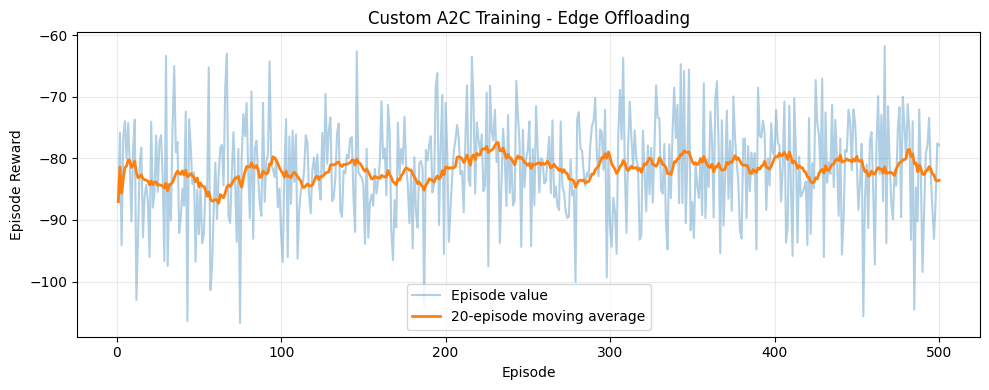

In [ ]:
print("\n" + "="*60)
print("PART 5: CUSTOM A2C ON EDGE OFFLOADING ENV")
print("="*60)

def train_a2c_offloading(episodes, gamma=0.95, actor_lr=3e-4, critic_lr=1e-3, entropy_coef=0.05):
    actor  = ActorNetwork(input_dim=4, hidden_dim=128, output_dim=2).to(device)
    critic = CriticNetwork(input_dim=4, hidden_dim=128).to(device)

    actor_optimizer  = optim.Adam(actor.parameters(),  lr=actor_lr)
    critic_optimizer = optim.Adam(critic.parameters(), lr=critic_lr)

    env = EdgeOffloadingEnv(max_steps=50)
    episode_returns = []

    for ep in range(episodes):
        state, _ = env.reset(seed=SEED + ep)
        done = False
        total_reward = 0.0

        log_probs_batch = []
        rewards_batch   = []
        values_batch    = []
        entropies_batch = []

        while not done:
            s_norm  = normalize_state(state)
            state_t = torch.tensor(s_norm, dtype=torch.float32, device=device).unsqueeze(0)

            probs   = actor(state_t).squeeze(0)
            value   = critic(state_t).squeeze(0)

            dist     = Categorical(probs)
            action   = dist.sample()
            log_prob = dist.log_prob(action)
            entropy  = dist.entropy()

            next_state, reward, terminated, truncated, _ = env.step(int(action.item()))
            done = terminated or truncated
            total_reward += reward

            log_probs_batch.append(log_prob)
            rewards_batch.append(reward)
            values_batch.append(value)
            entropies_batch.append(entropy)

            state = next_state

        episode_returns.append(total_reward)

        discounted_returns = []
        g_t = 0.0
        for r in reversed(rewards_batch):
            g_t = r + gamma * g_t
            discounted_returns.insert(0, g_t)

        returns_tensor   = torch.tensor(discounted_returns, dtype=torch.float32, device=device)
        values_tensor    = torch.stack(values_batch)
        log_probs_tensor = torch.stack(log_probs_batch)
        entropies_tensor = torch.stack(entropies_batch)

        advantages_tensor = returns_tensor - values_tensor.squeeze(-1)

        if advantages_tensor.std() > 1e-8:
            advantages_tensor = (advantages_tensor - advantages_tensor.mean()) / (advantages_tensor.std() + 1e-8)

        actor_loss  = -(log_probs_tensor * advantages_tensor.detach()).mean()
        actor_loss  = actor_loss - entropy_coef * entropies_tensor.mean()

        critic_loss = nn.functional.mse_loss(values_tensor.squeeze(-1), returns_tensor)

        actor_optimizer.zero_grad()
        actor_loss.backward()
        actor_optimizer.step()

        critic_optimizer.zero_grad()
        critic_loss.backward()
        critic_optimizer.step()

        if (ep + 1) % 100 == 0:
            print(f"A2C episode {ep+1}/{episodes} | return: {total_reward:.3f}")

    env.close()
    return actor, episode_returns


print("Training Custom A2C...")
_ep_a2c = 500 if FAST_MODE else 1000
a2c_custom_actor, a2c_custom_rewards = train_a2c_offloading(episodes=_ep_a2c, gamma=0.95, entropy_coef=0.05)
print(f"Training done. Last-50 avg reward: {np.mean(a2c_custom_rewards[-50:]):.4f}")
plot_curve(a2c_custom_rewards, "Custom A2C Training - Edge Offloading", "Episode Reward")


In [9]:
# ============================================================================
# Evaluate Custom A2C
# ============================================================================

a2c_custom_actor.eval()

def a2c_action_fn(state, env):
    s_norm  = normalize_state(state)
    state_t = torch.tensor(s_norm, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        probs = a2c_custom_actor(state_t).squeeze(0)
    return int(torch.argmax(probs).item())

a2c_result = evaluate_edge_policy(make_env, a2c_action_fn, episodes=100)
print(f"Custom A2C   | Avg Latency: {a2c_result['avg_latency']:.2f} ms | "
      f"P95: {a2c_result['p95_latency']:.2f} ms | "
      f"Avg Reward: {a2c_result['avg_reward']:.4f} | "
      f"Device%: {a2c_result['device_pct']:.1f} | Edge%: {a2c_result['edge_pct']:.1f}")


Custom A2C   | Avg Latency: 1447.72 ms | P95: 3339.49 ms | Avg Reward: -72.3861 | Device%: 11.2 | Edge%: 88.8


---

# PART 6: Final Comparison

We compare all methods (baseline policies, Actor-Critic, and A2C) using shared evaluation metrics.

### 7.1 Aggregated Results Table



FINAL COMPARISON TABLE
                Avg Latency ↓  P95 Latency ↓  Avg Reward ↑  Gap to Greedy ↓  Device %  Edge %
Method                                                                                       
Random               1641.766       3354.391       -82.088          509.485     50.44   49.56
Device-only          1533.064       2847.473       -76.653          400.784    100.00    0.00
Edge-only            1754.788       4478.385       -87.739          622.508      0.00  100.00
Greedy latency       1132.280       2346.855       -56.614            0.000     48.98   51.02
Actor-Critic         1235.141       2621.806       -61.757          102.860     60.12   39.88
A2C                  1447.721       3339.486       -72.386          315.441     11.22   88.78


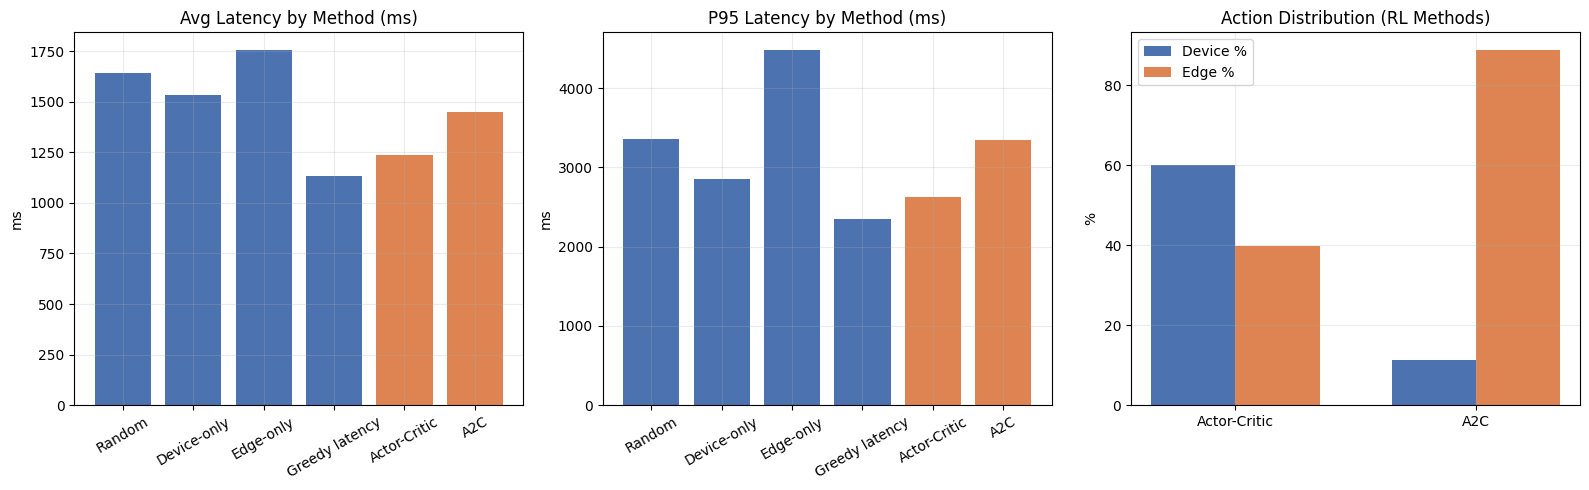

In [10]:
# ============================================================================
# Build comprehensive comparison table
# ============================================================================

comparison_rows = []

def add_result(method_name, result):
    """Add a result row to the comparison table.
    
    Args:
        method_name: Name of the method
        result: Evaluation result dictionary
    """
    comparison_rows.append({
        'Method':          method_name,
        'Avg Latency ↓':   result['avg_latency'],
        'P95 Latency ↓':   result['p95_latency'],
        'Avg Reward ↑':    result['avg_reward'],
        'Gap to Greedy ↓': result['avg_latency'] - baseline_results['Greedy latency']['avg_latency'],
        'Device %':         result['device_pct'],
        'Edge %':           result['edge_pct'],
    })

for name, result in baseline_results.items():
    add_result(name, result)
add_result('Actor-Critic', ac_result)
add_result('A2C',          a2c_result)

df_compare = pd.DataFrame(comparison_rows).set_index('Method')
print("\n" + "="*60)
print("FINAL COMPARISON TABLE")
print("="*60)
print(df_compare.round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

methods = df_compare.index.tolist()
avg_lat = df_compare['Avg Latency ↓'].values
p95_lat = df_compare['P95 Latency ↓'].values
dev_pct = df_compare['Device %'].values
edg_pct = df_compare['Edge %'].values

rl_methods = ['Actor-Critic', 'A2C']
rl_dev = [df_compare.loc[m, 'Device %'] for m in rl_methods]
rl_edg = [df_compare.loc[m, 'Edge %']   for m in rl_methods]

axes[0].bar(methods, avg_lat, color=['#4C72B0']*4 + ['#DD8452']*2)
axes[0].set_title('Avg Latency by Method (ms)')
axes[0].set_ylabel('ms')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(methods, p95_lat, color=['#4C72B0']*4 + ['#DD8452']*2)
axes[1].set_title('P95 Latency by Method (ms)')
axes[1].set_ylabel('ms')
axes[1].tick_params(axis='x', rotation=30)

x = np.arange(len(rl_methods))
w = 0.35
axes[2].bar(x - w/2, rl_dev, w, label='Device %', color='#4C72B0')
axes[2].bar(x + w/2, rl_edg, w, label='Edge %',   color='#DD8452')
axes[2].set_xticks(x)
axes[2].set_xticklabels(rl_methods)
axes[2].set_title('Action Distribution (RL Methods)')
axes[2].set_ylabel('%')
axes[2].legend()

plt.tight_layout()
plt.show()


## CONGRATULATIONS TEAM!

Congratulations on Completing Lab 04.2 - Policy-Based Reinforcement Learning for Edge Offloading!

**Key Observations:**

- **REINFORCE** is simple but often has high-variance updates.
- **Actor-Critic** is usually more stable due to TD-based critic guidance.
- **A2C** is a practical implementation of actor-critic methods.
- On EdgeOffloadingEnv, learned policies can approach strong heuristic behavior.
- The task highlights trade-offs between communication latency and compute placement decisions.

**Why This Matters:**

- Edge systems require fast adaptive offloading decisions.
- Policy-based RL provides a data-driven alternative to hand-crafted decision rules.
- These methods form a foundation for many advanced RL algorithms used in networking systems.

References: https://gymnasium.farama.org/ | https://pytorch.org/ | https://stable-baselines3.readthedocs.io/

## ADDITIONAL INFORMATION

**Author**: M.Sc. Phan Trung Phat - Department of Computer Networks and Communications, UIT

**Contact**: phatpt@uit.edu.vn

**Last Updated**: March, 2026